In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
from pathlib import Path

print("Current Working Directory:")
print(Path.cwd())

Current Working Directory:
e:\facial-recognition-attendance-system


In [3]:
from app.config.config import (
    WEIGHTS_PATH,
    CONF,
    IOU,
    IMG_SIZE,
    DEVICE
)

from app.detection.face_detector import FaceDetector
from app.recognition.face_recognizer import FaceRecognizer

# Import directly from your registration script
from app.register.register_student import (
    augment_face,
    compute_mean_embedding
)

In [4]:
from pathlib import Path

LFW_ROOT = Path(
    r"E:\final-year-project\working-files\dataset\recognition-lfw\lfw_funneled"
)

print("Dataset Exists :", LFW_ROOT.exists())
print("Dataset Path   :", LFW_ROOT)

Dataset Exists : True
Dataset Path   : E:\final-year-project\working-files\dataset\recognition-lfw\lfw_funneled


In [5]:
people = sorted([p for p in LFW_ROOT.iterdir() if p.is_dir()])

print(f"Total People : {len(people)}")

for person in people[:5]:
    print(person.name)

Total People : 5749
Aaron_Eckhart
Aaron_Guiel
Aaron_Patterson
Aaron_Peirsol
Aaron_Pena


In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
LFW_ROOT = Path(
    r"E:\final-year-project\working-files\dataset\recognition-lfw\lfw_funneled"
)

print("=" * 60)
print("Project Root :", PROJECT_ROOT)
print("Dataset Root :", LFW_ROOT)
print("=" * 60)

assert PROJECT_ROOT.exists(), "Project folder not found."
assert LFW_ROOT.exists(), "LFW dataset not found."

num_people = len([p for p in LFW_ROOT.iterdir() if p.is_dir()])

print(f"Found {num_people} identities.")

Project Root : e:\facial-recognition-attendance-system
Dataset Root : E:\final-year-project\working-files\dataset\recognition-lfw\lfw_funneled
Found 5749 identities.


In [7]:
detector = FaceDetector(
    WEIGHTS_PATH,
    device=DEVICE,
    conf=0.25,
    iou=0.5,
    img_size=320
)

recognizer = FaceRecognizer(device=DEVICE)

print("Models Loaded.")

[MODEL] Input  — name: input.1, shape: ['None', 3, 112, 112], type: tensor(float)
[MODEL] Output — name: 683, shape: [1, 512], type: tensor(float)
Models Loaded.


In [8]:
NUM_IDENTITIES = 500

In [9]:
identity_folders = sorted(
    [
        folder
        for folder in LFW_ROOT.iterdir()
        if folder.is_dir() and len(list(folder.glob("*.jpg"))) >= 2
    ]
)

if NUM_IDENTITIES is not None:
    identity_folders = identity_folders[:NUM_IDENTITIES]

print(f"Selected {len(identity_folders)} identities.\n")

for folder in identity_folders:
    print(folder.name)

Selected 500 identities.

Aaron_Peirsol
Aaron_Sorkin
Abdel_Nasser_Assidi
Abdoulaye_Wade
Abdullah
Abdullah_al-Attiyah
Abdullah_Gul
Abdullatif_Sener
Abel_Pacheco
Abid_Hamid_Mahmud_Al-Tikriti
Adam_Sandler
Adam_Scott
Adel_Al-Jubeir
Adolfo_Aguilar_Zinser
Adolfo_Rodriguez_Saa
Adrian_McPherson
Adrian_Nastase
Adrien_Brody
Ahmad_Masood
Ahmed_Chalabi
Ahmet_Necdet_Sezer
Ai_Sugiyama
Aicha_El_Ouafi
Aitor_Gonzalez
Akbar_Hashemi_Rafsanjani
Akhmed_Zakayev
Al_Davis
Al_Gore
Al_Pacino
Al_Sharpton
Alan_Ball
Alan_Greenspan
Alan_Mulally
Alastair_Campbell
Albert_Costa
Alberto_Fujimori
Alberto_Ruiz_Gallardon
Albrecht_Mentz
Aldo_Paredes
Alec_Baldwin
Alejandro_Atchugarry
Alejandro_Avila
Alejandro_Toledo
Aleksander_Kwasniewski
Alex_Barros
Alex_Penelas
Alex_Sink
Alexander_Downer
Alexander_Losyukov
Alexander_Rumyantsev
Alexandra_Stevenson
Alexandra_Vodjanikova
Ali_Abbas
Ali_Khamenei
Ali_Naimi
Alice_Fisher
Alicia_Silverstone
Alimzhan_Tokhtakhounov
Alison_Lohman
Allen_Iverson
Allison_Janney
Allyson_Felix
Alvaro_Nobo

In [10]:
def extract_face(image):

    detections = detector.predict(image)

    if len(detections) == 0:
        return None

    det = max(detections, key=lambda d: d["conf"])

    x1 = int(det["x1"])
    y1 = int(det["y1"])
    x2 = int(det["x2"])
    y2 = int(det["y2"])

    pad = 10

    x1 = max(0, x1-pad)
    y1 = max(0, y1-pad)
    x2 = min(image.shape[1], x2+pad)
    y2 = min(image.shape[0], y2+pad)

    face = image[y1:y2, x1:x2]

    if face.size == 0:
        return None

    return cv2.resize(face, (112,112))

In [11]:
def register_identity(folder):

    images = sorted(folder.glob("*.jpg"))

    registration_image = images[0]

    print(f"\nRegistering: {folder.name}")
    print(f"Using image: {registration_image.name}")

    image = cv2.imread(str(registration_image))

    if image is None:
        print("Failed to read image.")
        return None

    face = extract_face(image)

    if face is None:
        print("YOLO failed to detect face.")
        return None

    variants = augment_face(face)

    print(f"Generated {len(variants)} augmentations.")

    embeddings = []

    for aug in variants:

        emb = recognizer.get_embedding(aug)

        if emb is not None:
            embeddings.append(emb)

    print(f"Generated {len(embeddings)} embeddings.")

    if len(embeddings) == 0:
        print("No embeddings generated.")
        return None

    return {
        "embedding": compute_mean_embedding(embeddings),
        "registration_image": registration_image.name,
        "num_embeddings": len(embeddings)
    }

In [12]:
embedding_database = {}

print("Building Enrollment Database...\n")

for folder in identity_folders:

    data = register_identity(folder)

    if data is None:
        print(f"Failed : {folder.name}")
        continue

    embedding_database[folder.name] = data

    print(
        f"{folder.name:30s}"
        f"Registered "
        f"({data['num_embeddings']} embeddings)"
    )

print()

print(f"Database Size : {len(embedding_database)}")

Building Enrollment Database...


Registering: Aaron_Peirsol
Using image: Aaron_Peirsol_0001.jpg
Generated 30 augmentations.
Generated 30 embeddings.
Aaron_Peirsol                 Registered (30 embeddings)

Registering: Aaron_Sorkin
Using image: Aaron_Sorkin_0001.jpg
Generated 30 augmentations.
Generated 30 embeddings.
Aaron_Sorkin                  Registered (30 embeddings)

Registering: Abdel_Nasser_Assidi
Using image: Abdel_Nasser_Assidi_0001.jpg
Generated 30 augmentations.
Generated 30 embeddings.
Abdel_Nasser_Assidi           Registered (30 embeddings)

Registering: Abdoulaye_Wade
Using image: Abdoulaye_Wade_0001.jpg
Generated 30 augmentations.
Generated 30 embeddings.
Abdoulaye_Wade                Registered (30 embeddings)

Registering: Abdullah
Using image: Abdullah_0001.jpg
Generated 30 augmentations.
Generated 30 embeddings.
Abdullah                      Registered (30 embeddings)

Registering: Abdullah_al-Attiyah
Using image: Abdullah_al-Attiyah_0001.jpg
Generated 30 augmen

In [13]:
print()

for name, data in embedding_database.items():

    print(name)

    print("Registration Image :", data["registration_image"])

    print("Embedding Shape    :", data["embedding"].shape)

    print()


Aaron_Peirsol
Registration Image : Aaron_Peirsol_0001.jpg
Embedding Shape    : (512,)

Aaron_Sorkin
Registration Image : Aaron_Sorkin_0001.jpg
Embedding Shape    : (512,)

Abdel_Nasser_Assidi
Registration Image : Abdel_Nasser_Assidi_0001.jpg
Embedding Shape    : (512,)

Abdoulaye_Wade
Registration Image : Abdoulaye_Wade_0001.jpg
Embedding Shape    : (512,)

Abdullah
Registration Image : Abdullah_0001.jpg
Embedding Shape    : (512,)

Abdullah_al-Attiyah
Registration Image : Abdullah_al-Attiyah_0001.jpg
Embedding Shape    : (512,)

Abdullah_Gul
Registration Image : Abdullah_Gul_0001.jpg
Embedding Shape    : (512,)

Abdullatif_Sener
Registration Image : Abdullatif_Sener_0001.jpg
Embedding Shape    : (512,)

Abel_Pacheco
Registration Image : Abel_Pacheco_0001.jpg
Embedding Shape    : (512,)

Abid_Hamid_Mahmud_Al-Tikriti
Registration Image : Abid_Hamid_Mahmud_Al-Tikriti_0001.jpg
Embedding Shape    : (512,)

Adam_Sandler
Registration Image : Adam_Sandler_0001.jpg
Embedding Shape    : (512,)

In [14]:
def cosine_similarity(a, b):
    return float(np.dot(a, b))

In [15]:
def recognize(face):

    emb = recognizer.get_embedding(face)

    if emb is None:
        return None, -1

    best_person = None
    best_score = -1

    for person, data in embedding_database.items():

        score = cosine_similarity(
            emb,
            data["embedding"]
        )

        if score > best_score:

            best_score = score
            best_person = person

    return best_person, best_score

In [16]:
print("="*60)

print("Enrollment Summary")

print("="*60)

print("Total Identities :", len(embedding_database))

print()

for person in embedding_database:

    print(person)

Enrollment Summary
Total Identities : 500

Aaron_Peirsol
Aaron_Sorkin
Abdel_Nasser_Assidi
Abdoulaye_Wade
Abdullah
Abdullah_al-Attiyah
Abdullah_Gul
Abdullatif_Sener
Abel_Pacheco
Abid_Hamid_Mahmud_Al-Tikriti
Adam_Sandler
Adam_Scott
Adel_Al-Jubeir
Adolfo_Aguilar_Zinser
Adolfo_Rodriguez_Saa
Adrian_McPherson
Adrian_Nastase
Adrien_Brody
Ahmad_Masood
Ahmed_Chalabi
Ahmet_Necdet_Sezer
Ai_Sugiyama
Aicha_El_Ouafi
Aitor_Gonzalez
Akbar_Hashemi_Rafsanjani
Akhmed_Zakayev
Al_Davis
Al_Gore
Al_Pacino
Al_Sharpton
Alan_Ball
Alan_Greenspan
Alan_Mulally
Alastair_Campbell
Albert_Costa
Alberto_Fujimori
Alberto_Ruiz_Gallardon
Albrecht_Mentz
Aldo_Paredes
Alec_Baldwin
Alejandro_Atchugarry
Alejandro_Avila
Alejandro_Toledo
Aleksander_Kwasniewski
Alex_Barros
Alex_Penelas
Alex_Sink
Alexander_Downer
Alexander_Losyukov
Alexander_Rumyantsev
Alexandra_Stevenson
Alexandra_Vodjanikova
Ali_Abbas
Ali_Khamenei
Ali_Naimi
Alice_Fisher
Alicia_Silverstone
Alimzhan_Tokhtakhounov
Alison_Lohman
Allen_Iverson
Allison_Janney
Allyson_

In [49]:
results = []

print("Running Recognition...\n")

for folder in identity_folders:

    person = folder.name

    images = sorted(folder.glob("*.jpg"))

    # Skip registration image
    test_images = images

    for image_path in test_images:

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        face = extract_face(image)

        if face is None:
            continue

        prediction, similarity = recognize(face)

        results.append({
            "true_person": person,
            "predicted_person": prediction,
            "similarity": similarity,
            "image_name": image_path.name
        })

print(f"\nTotal Test Images : {len(results)}")

Running Recognition...


Total Test Images : 2478


In [50]:
for r in results[:20]:

    print(
        f'{r["true_person"]:30s}'
        f' --> '
        f'{r["predicted_person"]:30s}'
        f'{r["similarity"]:.4f}'
    )

Aaron_Peirsol                  --> Aaron_Peirsol                 0.9873
Aaron_Peirsol                  --> Aaron_Peirsol                 0.7162
Aaron_Peirsol                  --> Aaron_Peirsol                 0.6820
Aaron_Peirsol                  --> Aaron_Peirsol                 0.4894
Aaron_Sorkin                   --> Aaron_Sorkin                  0.9746
Aaron_Sorkin                   --> Aaron_Sorkin                  0.5842
Abdel_Nasser_Assidi            --> Abdel_Nasser_Assidi           0.9878
Abdel_Nasser_Assidi            --> Abdel_Nasser_Assidi           0.8218
Abdoulaye_Wade                 --> Abdoulaye_Wade                0.9818
Abdoulaye_Wade                 --> Abdoulaye_Wade                0.5899
Abdoulaye_Wade                 --> Dino_de_Laurentis             0.4088
Abdoulaye_Wade                 --> Abdoulaye_Wade                0.5299
Abdullah                       --> Abdullah                      0.9883
Abdullah                       --> Abdullah                     

In [51]:
y_true = []
y_pred = []
similarities = []

for r in results:

    y_true.append(r["true_person"])
    y_pred.append(r["predicted_person"])
    similarities.append(r["similarity"])

In [52]:
print("Similarity Statistics\n")

print(f"Minimum : {np.min(similarities):.4f}")
print(f"Maximum : {np.max(similarities):.4f}")
print(f"Mean    : {np.mean(similarities):.4f}")
print(f"Median  : {np.median(similarities):.4f}")

Similarity Statistics

Minimum : 0.1691
Maximum : 0.9922
Mean    : 0.6441
Median  : 0.6129


In [53]:
THRESHOLD = 0.50

In [54]:
final_predictions = []

for r in results:

    if r["similarity"] >= THRESHOLD:

        final_predictions.append(
            r["predicted_person"]
        )

    else:

        final_predictions.append("Unknown")

In [55]:
unknown = final_predictions.count("Unknown")

known = len(final_predictions) - unknown

print("Known Predictions   :", known)

print("Unknown Predictions :", unknown)

print("Unknown %           :", round(
    unknown / len(final_predictions) * 100,
    2
))

Known Predictions   : 1897
Unknown Predictions : 581
Unknown %           : 23.45


In [56]:
for i in range(min(25, len(results))):

    print(
        f"{results[i]['image_name']:35s}"
        f"{results[i]['true_person']:30s}"
        f"{final_predictions[i]:30s}"
        f"{results[i]['similarity']:.4f}"
    )

Aaron_Peirsol_0001.jpg             Aaron_Peirsol                 Aaron_Peirsol                 0.9873
Aaron_Peirsol_0002.jpg             Aaron_Peirsol                 Aaron_Peirsol                 0.7162
Aaron_Peirsol_0003.jpg             Aaron_Peirsol                 Aaron_Peirsol                 0.6820
Aaron_Peirsol_0004.jpg             Aaron_Peirsol                 Unknown                       0.4894
Aaron_Sorkin_0001.jpg              Aaron_Sorkin                  Aaron_Sorkin                  0.9746
Aaron_Sorkin_0002.jpg              Aaron_Sorkin                  Aaron_Sorkin                  0.5842
Abdel_Nasser_Assidi_0001.jpg       Abdel_Nasser_Assidi           Abdel_Nasser_Assidi           0.9878
Abdel_Nasser_Assidi_0002.jpg       Abdel_Nasser_Assidi           Abdel_Nasser_Assidi           0.8218
Abdoulaye_Wade_0001.jpg            Abdoulaye_Wade                Abdoulaye_Wade                0.9818
Abdoulaye_Wade_0002.jpg            Abdoulaye_Wade                Abdoulaye_Wade   

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

In [58]:
thresholds = np.arange(0.30, 0.96, 0.01)

best_threshold = 0
best_accuracy = 0
best_precision = 0
best_recall = 0
best_f1 = 0

for threshold in thresholds:

    y_true = []
    y_pred = []

    for r in results:

        y_true.append(r["true_person"])

        if r["similarity"] >= threshold:
            y_pred.append(r["predicted_person"])
        else:
            y_pred.append("Unknown")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_threshold = threshold
        best_precision = precision
        best_recall = recall
        best_f1 = f1

print(f"Best Threshold : {best_threshold:.2f}")

Best Threshold : 0.30


In [59]:
print("="*60)
print("FINAL RESULTS")
print("="*60)

print(f"Threshold : {best_threshold:.2f}")

print()

print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")

FINAL RESULTS
Threshold : 0.30

Accuracy  : 0.9536
Precision : 0.9831
Recall    : 0.9466
F1 Score  : 0.9570


In [60]:
y_true = []
y_pred = []

for r in results:

    y_true.append(r["true_person"])

    if r["similarity"] >= best_threshold:
        y_pred.append(r["predicted_person"])
    else:
        y_pred.append("Unknown")

In [61]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[4 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 0]]


In [62]:
print(

    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

)

                              precision    recall  f1-score   support

               Aaron_Peirsol       1.00      1.00      1.00         4
                Aaron_Sorkin       0.67      1.00      0.80         2
         Abdel_Nasser_Assidi       1.00      1.00      1.00         2
              Abdoulaye_Wade       1.00      0.75      0.86         4
                    Abdullah       1.00      1.00      1.00         4
                Abdullah_Gul       1.00      0.89      0.94        19
         Abdullah_al-Attiyah       1.00      1.00      1.00         3
            Abdullatif_Sener       1.00      1.00      1.00         2
                Abel_Pacheco       1.00      1.00      1.00         4
Abid_Hamid_Mahmud_Al-Tikriti       1.00      1.00      1.00         3
                Adam_Sandler       1.00      1.00      1.00         4
                  Adam_Scott       1.00      1.00      1.00         2
              Adel_Al-Jubeir       1.00      1.00      1.00         3
       Adolfo_Aguil

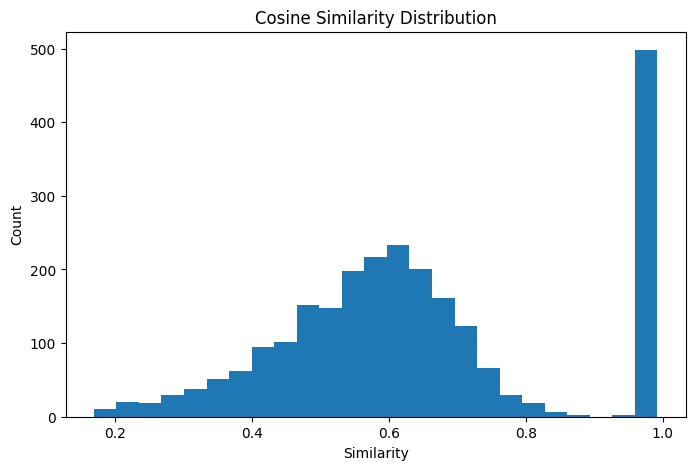

In [63]:
scores = [r["similarity"] for r in results]

plt.figure(figsize=(8,5))

plt.hist(scores, bins=25)

plt.title("Cosine Similarity Distribution")

plt.xlabel("Similarity")

plt.ylabel("Count")

plt.show()

In [64]:
errors = []

for r in results:

    prediction = (
        r["predicted_person"]
        if r["similarity"] >= best_threshold
        else "Unknown"
    )

    if prediction != r["true_person"]:

        errors.append({

            "image": r["image_name"],
            "true": r["true_person"],
            "pred": prediction,
            "score": r["similarity"]

        })

print(f"Total Errors : {len(errors)}")

Total Errors : 115


In [65]:
for e in errors:

    print(
        f'{e["image"]:35s}'
        f'{e["true"]:30s}'
        f'{e["pred"]:30s}'
        f'{e["score"]:.4f}'
    )

Abdoulaye_Wade_0003.jpg            Abdoulaye_Wade                Dino_de_Laurentis             0.4088
Abdullah_Gul_0002.jpg              Abdullah_Gul                  Unknown                       0.2783
Abdullah_Gul_0016.jpg              Abdullah_Gul                  Unknown                       0.2833
Adolfo_Rodriguez_Saa_0002.jpg      Adolfo_Rodriguez_Saa          Brad_Garrett                  0.3439
Ahmad_Masood_0002.jpg              Ahmad_Masood                  Frank_Dunham_Jr               0.3255
Alastair_Campbell_0002.jpg         Alastair_Campbell             Bill_Belichick                0.4075
Alejandro_Toledo_0018.jpg          Alejandro_Toledo              Federico_Trillo               0.3123
Alejandro_Toledo_0028.jpg          Alejandro_Toledo              Unknown                       0.2332
Alison_Lohman_0002.jpg             Alison_Lohman                 Unknown                       0.2743
Alvaro_Silva_Calderon_0002.jpg     Alvaro_Silva_Calderon         Unknown          

In [66]:
successful = sum(
    r["predicted_person"] != "Detection Failed"
    for r in results
)

failed = len(results) - successful

print(f"Successful Detections : {successful}")
print(f"Failed Detections     : {failed}")

print(f"Detection Rate        : {successful/len(results):.4f}")

Successful Detections : 2478
Failed Detections     : 0
Detection Rate        : 1.0000


In [ ]:
import pandas as pd

df = pd.DataFrame(results)

df.to_csv(
    "lfw_results.csv",
    index=False
)

print("Saved to lfw_results.csv")